In [1]:
# basic python
import random
from pathlib import Path

# data science libraries
import numpy as np
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt

import sys
sys.path.append('../')  # to import from parent directory

from conformal_clustering.utils import ConformalClustering, label_alignment
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA


from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
from matplotlib import colors as mcolors

### Helper functions for heatmap plots

In [2]:
def lighten_toward_white(rgb, alpha):
    """alpha in [0,1]: 0 = no change, 1 = white."""
    return (1 - alpha) * rgb + alpha * 1.0

def labels_to_color(labels_like, n_classes=5, base_alpha=0.05):
    """
    - If labels_like is an int -> use that core color.
    - If it's an iterable -> take the mean of the cores in it,
      then 'intensify by number of labels' by moving toward white
      with alpha = base_alpha * (k-1), where k = set size.
      (More labels -> lighter background.) 
    """
    # normalize to a Python set of ints
    if isinstance(labels_like, (int, np.integer)):
        S = {int(labels_like)}
    else:
        S = {int(x) for x in labels_like}
        

    # empty set -> white
    if len(S) == 0:
        return np.array([1.0, 1.0, 1.0], float)

    # mean of the present cores
    mean_rgb = np.mean([core_rgb[i] for i in S], axis=0)

    # intensity control by subset size k
    k = len(S)
    alpha = min(1.0, base_alpha * (k - 1))  # more labels -> lighter
    return lighten_toward_white(mean_rgb, alpha)

def make_category_palette(categories):
    pool = [
        "#1affb7","#dd74ed","#ff7f00","#ffff21","#b1c5f3", "#42ebf7","#4F72FF",
        "#ffbbdf","#fc8d62","#4daf4a","#88CCEE","#e78ac3","#ffd92f","#e5c494","#b3b3b3",
        "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f",
        "#bcbd22","#17becf","#e41a1c","#377eb8",
        "#332288","#117733","#44AA99","#a65628","#DDCC77","#CC6677","#AA4499","#882255","#999933"
    ]
    if len(categories) > len(pool):
        raise ValueError(f"Need {len(categories)} colors, but pool has only {len(pool)}.")
    palette = {cat: pool[i] for i, cat in enumerate(categories)}
    cmap = ListedColormap([palette[cat] for cat in categories])
    return palette, cmap

def style_ax(ax):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_alpha(0.8)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

K = 8
palette, hydra_cmap = make_category_palette(np.arange(K))
core_rgb = {k: np.array(mcolors.to_rgb(v), float) for k, v in palette.items()}

# --- 6) Define dark colors for training points ---
def darken(rgb, factor=0.15):  # 0.15 = 15% darker
    return np.clip(rgb * (1 - factor), 0, 1)

dark_colors = {k: darken(core_rgb[k], 0.15) for k in core_rgb}

### Loading the data and checking the dimensions

In [3]:
# Try to locate the repo root by searching upwards for "Reproducible_Code"
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "Reproducible_Code").exists()), None)

if repo_root is None:
    raise FileNotFoundError(
        "Could not locate the 'Reproducible_Code' folder by searching parents of the current working directory. "
        "Set repo_root manually or run the notebook from within the repository."
    )

data_path = repo_root / "Reproducible_Code" / "Data" / "PBMC_dict.npy"

pbmc_dict = np.load(data_path, allow_pickle=True).item()
print(pbmc_dict.keys())

X_pbmc = pbmc_dict["norm_data"]         # processed expression matrix
X_raw  = pbmc_dict["raw_counts"]        # raw counts
y_pbmc = pbmc_dict["spectral_labels"]   # marker-based labels

print(X_pbmc.shape)
print(X_raw.shape)
print(y_pbmc.shape)

# Combine the cell types "CD4 T cells" and "Megakaryocytes" into a single group called "CD4 T + Megakaryocytes"

y_pbmc_combined = np.where(y_pbmc == "CD4 T cells", "CD4 T + Megakaryocytes", y_pbmc)
y_pbmc_combined = np.where(y_pbmc_combined == "Megakaryocytes", "CD4 T + Megakaryocytes", y_pbmc_combined)

dict_keys(['norm_data', 'raw_counts', 'spectral_labels'])
(2638, 2000)
(2638, 2000)
(2638,)


## Applying Split-CC in the original space

In [4]:
# def visualize(seed1, seed2):
#     X_rest, X_test, y_rest, y_test = train_test_split(X_pbmc, y_pbmc_combined, test_size=0.25, random_state=seed1)
#     X_train, X_calib, y_train, y_calib = train_test_split(X_rest, y_rest, test_size=0.5, random_state=seed2)

#     pca_all = PCA(n_components=2, random_state=0)
#     pca_all.fit(X_pbmc)

#     X_train_pca = pca_all.transform(X_train)   # shape: (n_train, K)
#     X_calib_pca = pca_all.transform(X_calib)   # shape: (n_calib, K)
#     X_test_pca = pca_all.transform(X_test)   # shape: (n_test, K)

#     le = LabelEncoder()
#     y_train = le.fit_transform(y_train)      # 0,...,K-1
#     y_calib = le.transform(y_calib)    # 0,...,K-1
#     y_test = le.transform(y_test)    # 0,...,K-1

#     # Create legend handles using original class names
#     legend_handles = [
#         Line2D(
#             [0], [0],
#             marker='o',
#             color='w',
#             label=le.classes_[k],
#             markerfacecolor=core_rgb[k],
#             markeredgecolor='black',
#             markeredgewidth=0.3,
#             markersize=7
#         )
#         for k in range(len(le.classes_))
#     ]

#     fig, axes = plt.subplots(1, 3, figsize=(14, 5))
#     ax_left, ax_middle, ax_right = axes
#     # --- Left: Training data with true labels ---
#     ax_left.scatter(
#         X_train_pca[:, 0], X_train_pca[:, 1],
#         s=20,
#         color=[core_rgb[k] for k in y_train],
#         edgecolors="black",
#         linewidths=0.3,
#         rasterized=True
#     )
#     ax_left.set_title("Training data (PCA): True labels")
#     ax_left.set_xlabel("PC1")
#     ax_left.set_ylabel("PC2")

#     # --- Middle: Calibration data with true labels ---
#     ax_middle.scatter(
#         X_calib_pca[:, 0], X_calib_pca[:, 1],
#         s=20,
#         color=[core_rgb[k] for k in y_calib],
#         edgecolors="black",
#         linewidths=0.3,
#         rasterized=True
#     )
#     ax_middle.set_title("Calibration data (PCA): True labels")
#     ax_middle.set_xlabel("PC1")
#     ax_middle.set_ylabel("PC2")

#     # --- Right: Test data with true labels ---
#     ax_right.scatter(
#         X_test_pca[:, 0], X_test_pca[:, 1],
#         s=20,
#         color=[core_rgb[k] for k in y_test],
#         edgecolors="black",
#         linewidths=0.3,
#         rasterized=True
#     )
#     ax_right.set_title("Test data (PCA): True labels")
#     ax_right.set_xlabel("PC1")
#     ax_right.set_ylabel("PC2")  

#     ax_left.legend(handles=legend_handles, loc="best", fontsize=8)
#     ax_middle.legend(handles=legend_handles, loc="best", fontsize=8)
#     ax_right.legend(handles=legend_handles, loc="best", fontsize=8)

#     fig.tight_layout()
#     plt.show()



In [5]:
# visualize(seed1=7, seed2=8)

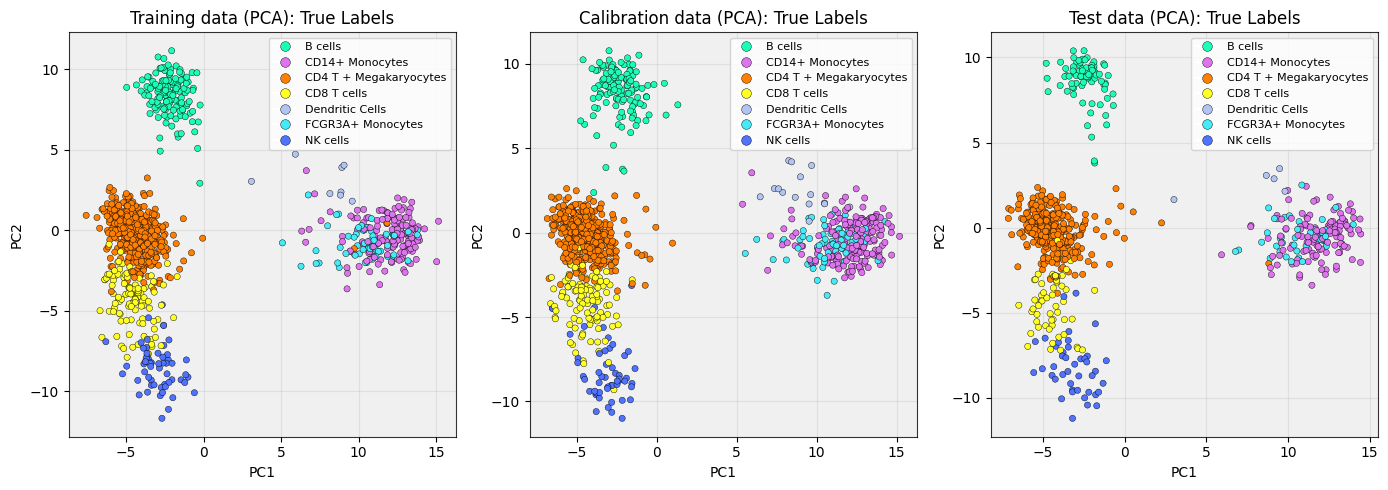

In [6]:
# 7/5
seed1 = 7
seed2 = 5

X_rest, X_test, y_rest, y_test, rest_idx, test_idx = train_test_split(X_pbmc, y_pbmc_combined, np.arange(X_pbmc.shape[0]), test_size=0.25, random_state=seed1)
X_train, X_calib, y_train, y_calib, train_idx, calib_idx = train_test_split(X_rest, y_rest, rest_idx, test_size=0.5, random_state=seed2)

pca_all = PCA(n_components=2, random_state=0)
pca_all.fit(X_pbmc)

le = LabelEncoder()
le.fit(y_pbmc_combined)  # Fit on the entire dataset to capture all classes

X_train_pca = pca_all.transform(X_train)   # shape: (n_train, K)
X_calib_pca = pca_all.transform(X_calib)   # shape: (n_calib, K)
X_test_pca = pca_all.transform(X_test)   # shape: (n_test, K)


y_train_encoded = le.transform(y_train)      # 0,...,K-1
y_calib_encoded = le.transform(y_calib)    # 0,...,K-1
y_test_encoded = le.transform(y_test)    # 0,...,K-1

# Create legend handles using original class names
legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=le.classes_[k],
        markerfacecolor=core_rgb[k],
        markeredgecolor='black',
        markeredgewidth=0.3,
        markersize=7
    )
    for k in range(len(le.classes_))
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
ax_left, ax_middle, ax_right = axes
# --- Left: Training data with true labels ---
style_ax(ax_left)
ax_left.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    s=20,
    color=[core_rgb[k] for k in y_train_encoded],
    edgecolors="black",
    linewidths=0.3,
    rasterized=True
)
ax_left.set_title("Training data (PCA): True Labels")
ax_left.set_xlabel("PC1")
ax_left.set_ylabel("PC2")

# --- Middle: Calibration data with true labels ---
style_ax(ax_middle)
ax_middle.scatter(
    X_calib_pca[:, 0], X_calib_pca[:, 1],
    s=20,
    color=[core_rgb[k] for k in y_calib_encoded],
    edgecolors="black",
    linewidths=0.3,
    rasterized=True
)
ax_middle.set_title("Calibration data (PCA): True Labels")
ax_middle.set_xlabel("PC1")
ax_middle.set_ylabel("PC2")

# --- Right: Test data with true labels ---
style_ax(ax_right)
ax_right.scatter(
    X_test_pca[:, 0], X_test_pca[:, 1],
    s=20,
    color=[core_rgb[k] for k in y_test_encoded],
    edgecolors="black",
    linewidths=0.3,
    rasterized=True
)
ax_right.set_title("Test data (PCA): True Labels")
ax_right.set_xlabel("PC1")
ax_right.set_ylabel("PC2")  

ax_left.legend(handles=legend_handles, loc="best", fontsize=8)
ax_middle.legend(handles=legend_handles, loc="best", fontsize=8)
ax_right.legend(handles=legend_handles, loc="best", fontsize=8)

fig.tight_layout()
plt.show()

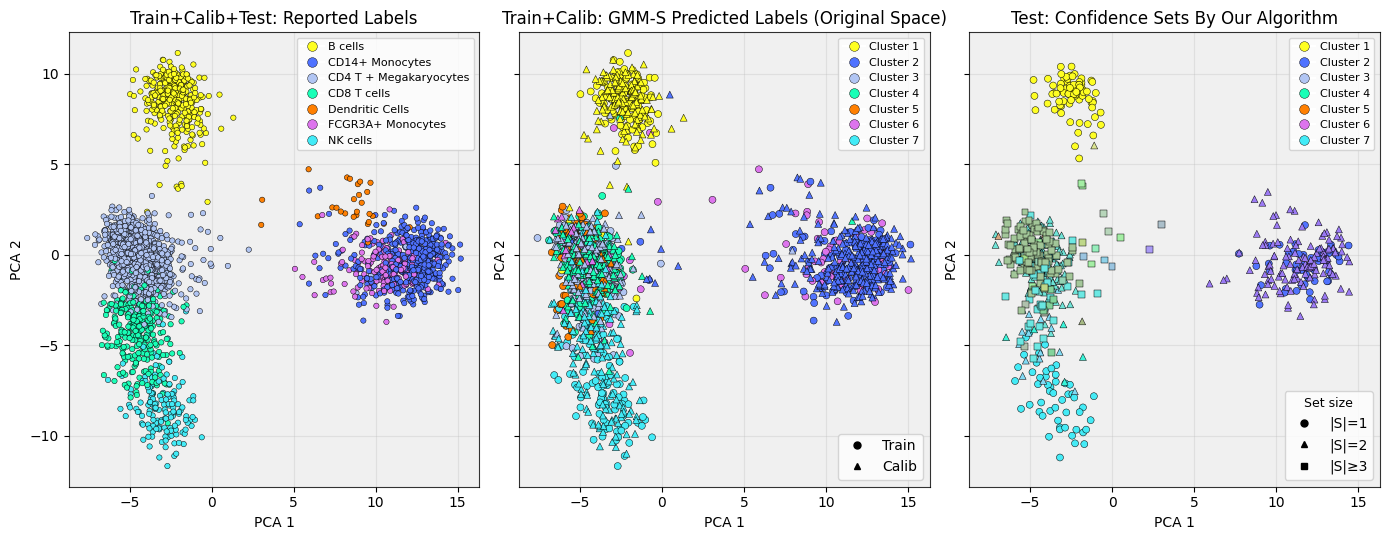

In [7]:
## Run the Split-CC algorithm on the data

K = 7  # Set number of clusters
alpha = 0.1

cc = ConformalClustering(X_train, X_calib, alpha=alpha)
# cc.set_classifier('SVC', C=0.250, probability=True)
cc.set_classifier('RF', random_state=0) # 3
# cc.fit('FCMS', c=K, m=1.25, error=0.005, maxiter=1000, seed=0)
cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++', covariance_type="diag", random_state=1070)

oracle_alignment_original = label_alignment(cc.y_tr, y_train_encoded, K)

# -----------------------------
# Data + conformal sets
# -----------------------------
X_pca_all = pca_all.transform(X_pbmc)   # shape: (n_total, K)
y_all_encoded = le.transform(y_pbmc_combined)  # shape: (n_total,)

X_pca_rest = pca_all.transform(X_rest)   # shape: (n_rest, K)
X_pca_test = pca_all.transform(X_test)   # shape: (n_test, K)

y_rest_encoded = le.transform(y_rest)    # shape: (n_rest,)
y_test_encoded = le.transform(y_test)    # shape: (n_test,)

predictions_boolean_rest = cc.conformal_set(X_rest)
predictions_boolean_test = cc.conformal_set(X_test)

# Colors for split-CC plots (use your labels_to_color)
rest_colors = np.array([
    labels_to_color(np.where(predictions_boolean_rest[i])[0])
    for i in range(predictions_boolean_rest.shape[0])
])
test_colors = np.array([
    labels_to_color(np.where(predictions_boolean_test[i])[0])
    for i in range(predictions_boolean_test.shape[0])
])

# True-label colors (use your core_rgb + oracle_alignment mapping)
true_colors_all = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_all_encoded])
true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest_encoded])
true_colors_test = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_test_encoded])

# Legend handles (true labels) -- unify across both splits so legend is consistent
all_unique_labels = np.unique(np.concatenate([y_rest_encoded, y_test_encoded])).astype(int)
true_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=le.classes_[k],
        # label = f"Cluster {k+1}",
        markerfacecolor=core_rgb[oracle_alignment_original[k]],
        markeredgecolor='black',
        markeredgewidth=0.3,
        markersize=7
    )
    for k in range(len(le.classes_))
]

cluster_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        # label=le.classes_[k],
        label = f"Cluster {k+1}",
        markerfacecolor=core_rgb[oracle_alignment_original[k]],
        markeredgecolor='black',
        markeredgewidth=0.3,
        markersize=7
    )
    for k in range(len(le.classes_))
]

# Set-size legend handles (all black)
setsize_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=1'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|=2'),
    Line2D([0],[0], marker='s', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='|S|≥3'),
]

# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]

# Marker grouping helper
def marker_group_from_boolean(pred_bool):
    set_sizes = pred_bool.sum(axis=1)
    return np.where(set_sizes == 1, 1, np.where(set_sizes == 2, 2, 3))

marker_map = {1: "o", 2: "^", 3: "s"}
marker_group_rest = marker_group_from_boolean(predictions_boolean_rest)
marker_group_test = marker_group_from_boolean(predictions_boolean_test)

# -----------------------------
# Plot styling helper
# -----------------------------
def style_ax(ax):
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, alpha=0.25)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_alpha(0.8)
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

# -----------------------------
# 4-panel figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

# Panel 1: Train+Calib true
ax = axes[0]
style_ax(ax)
ax.set_title("Train+Calib+Test: Reported Labels")
ax.scatter(
    X_pca_all[:, 0], X_pca_all[:, 1],
    c=true_colors_all, s=15, alpha=0.99, marker="o",
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.legend(handles=true_handles, loc="best",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.5, handletextpad=0.4)

# Panel 2: Train+Calib split-CC
ax = axes[1]
style_ax(ax)
ax.set_title("Train+Calib: GMM-S Predicted Labels (Original Space)")
ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    s=25, alpha=0.99, marker="o",
    color = [core_rgb[k] for k in cc.y_tr],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
ax.scatter(
    X_calib_pca[:, 0], X_calib_pca[:, 1],
    s=25, alpha=0.99, marker="^",
    color = [core_rgb[k] for k in cc.y_cal_al],  # color by true label
    edgecolors="black", linewidths=0.35, rasterized=True
)
leg_set = ax.legend(handles=tc_handles, 
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=cluster_handles, loc="best",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.5, handletextpad=0.4)

# # Panel 3: Test true
# ax = axes[2]
# style_ax(ax)
# ax.set_title("Test: True labels")
# ax.scatter(
#     X_pca_test[:, 0], X_pca_test[:, 1],
#     c=true_colors_test, s=25, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35, rasterized=True
# )
# ax.legend(handles=true_handles, title="True label", loc="best",
#           frameon=True, fontsize=8, title_fontsize=9,
#           borderpad=0.4, labelspacing=0.3, handletextpad=0.4)

# Panel 4: Test split-CC
ax = axes[2]
style_ax(ax)
ax.set_title("Test: Confidence Sets By Our Algorithm")
for g in [1, 2, 3]:
    idx = (marker_group_test == g)
    ax.scatter(
        X_pca_test[idx, 0], X_pca_test[idx, 1],
        c=test_colors[idx], s=25, alpha=0.99, marker=marker_map[g],
        edgecolors="black", linewidths=0.35, rasterized=True
    )
leg_set = ax.legend(handles=setsize_handles, title="Set size",
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax.add_artist(leg_set)
ax.legend(handles=cluster_handles, loc="best",
          frameon=True, fontsize=8, title_fontsize=9,
          borderpad=0.4, labelspacing=0.5, handletextpad=0.4)

fig.tight_layout()
plt.savefig("Figures/PBMC_original_space_GMMS.pdf", bbox_inches='tight')
plt.show()

## Applying Split-CC to the projected space

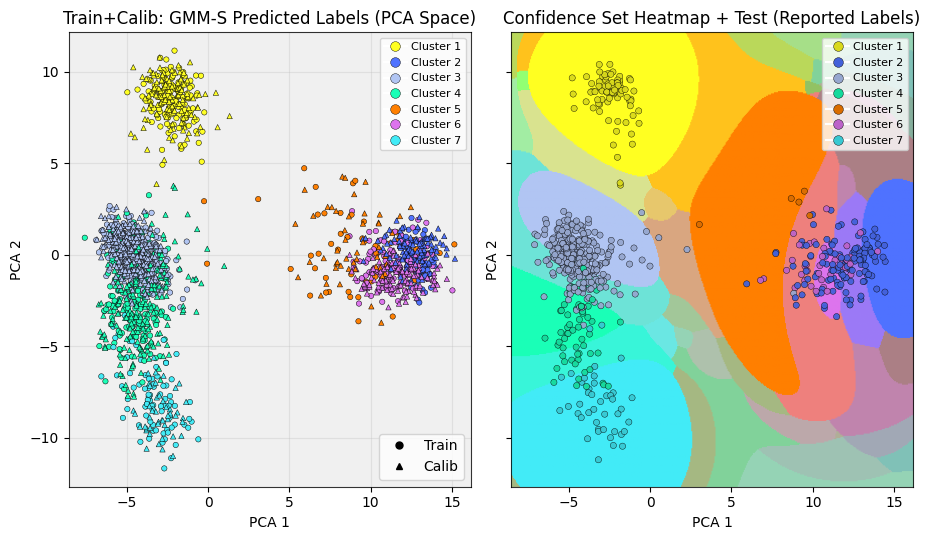

In [8]:
# pca_train = PCA(n_components=2, random_state=0)
# X_train_pca = pca_train.fit_transform(X_train)   # shape: (n_train, K)
X_train_pca = pca_all.transform(X_train)   # shape: (n_train, K)

# pca_calib = PCA(n_components=2, random_state=0)
# X_calib_pca = pca_calib.fit_transform(X_calib)   # shape: (n_calib, K)
X_calib_pca = pca_all.transform(X_calib)   # shape: (n_calib, K)

# pca_test = PCA(n_components=2, random_state=0)
# X_test_pca = pca_test.fit_transform(X_test)   # shape: (n_test, K)
X_test_pca = pca_all.transform(X_test)   # shape: (n_test, K)

x_min = min(X_train_pca[:, 0].min(), X_calib_pca[:, 0].min(), X_test_pca[:, 0].min()) - 1
x_max = max(X_train_pca[:, 0].max(), X_calib_pca[:, 0].max(), X_test_pca[:, 0].max()) + 1
y_min = min(X_train_pca[:, 1].min(), X_calib_pca[:, 1].min(), X_test_pca[:, 1].min()) - 1
y_max = max(X_train_pca[:, 1].max(), X_calib_pca[:, 1].max(), X_test_pca[:, 1].max()) + 1
K = 7  # Set number of clusters
alpha = 0.1
res = 400

cc = ConformalClustering(X_train_pca, X_calib_pca, alpha=alpha)
cc.set_classifier('SVC', C=0.50, probability=True, random_state=0)
cc.fit('GMMS', n_components=K, n_init=20, init_params='k-means++', random_state=0)

oracle_alignment_projected = label_alignment(cc.y_tr, y_train_encoded, K)

oracle_alignment_original = oracle_alignment_original.astype(int)
oracle_alignment_projected = oracle_alignment_projected.astype(int)

# Invert projected: projected -> train
inv_oracle_alignment_projected = np.empty(K, dtype=int)
inv_oracle_alignment_projected[oracle_alignment_projected] = np.arange(K, dtype=int)

# Compose: projected -> train -> original
oracle_alignment_projected_matched_to_original = (
    oracle_alignment_original[inv_oracle_alignment_projected]
)

# 1. Define the grid
x_range = np.linspace(x_min, x_max, res)
y_range = np.linspace(y_min, y_max, res)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
grid_points = np.column_stack((X_grid.ravel(), Y_grid.ravel()))  # (N, 2)

predictions_boolean = cc.conformal_set(grid_points)


X_rest_pca = pca_all.transform(X_rest)   # shape: (n_rest, K)
y_rest_encoded = le.transform(y_rest)    # shape: (n_rest,)

true_colors_rest = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_rest_encoded])
true_colors_all = np.array([core_rgb[int(oracle_alignment_original[int(lab)])] for lab in y_all_encoded])

true_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        # label=le.classes_[k],
        label = f"Cluster {k+1}",
        markerfacecolor=core_rgb[oracle_alignment_original[k]],
        markeredgecolor='black',
        markeredgewidth=0.3,
        markersize=7
    )
    for k in range(len(le.classes_))
]

fig, ax = plt.subplots(
    1, 2, figsize=(28/3, 5.5),
    sharex=True, sharey=True
)
fig.patch.set_facecolor("white")

# ============================================================
# LEFT: Train+Calib true labels
# ============================================================
# style_ax(ax[0])
# ax[0].set_title("Train+Calib: Reported labels")

# ax[0].scatter(
#     X_pca_rest[:, 0], X_pca_rest[:, 1],
#     c=true_colors_rest,
#     s=15, alpha=0.99, marker="o",
#     edgecolors="black", linewidths=0.35,
#     rasterized=True
# )

# ax[0].legend(
#     handles=true_handles,
#     loc="best",
#     frameon=True,
#     fontsize=8,
#     title_fontsize=9,
#     borderpad=0.4,
#     labelspacing=0.3,
#     handletextpad=0.4
# )

style_ax(ax[0])
ax[0].set_title("Train+Calib: GMM-S Predicted Labels (PCA Space)")
ax[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_tr]],
               s=15, alpha=0.99, marker="o",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
ax[0].scatter(X_calib_pca[:, 0], X_calib_pca[:, 1],
               c=[core_rgb[k] for k in oracle_alignment_projected_matched_to_original[cc.y_cal_al]],
               s=15, alpha=0.99, marker="^",
               edgecolors="black", linewidths=0.35,
               rasterized=True
)
# Train/calib marker grouping helper
tc_handles = [
    Line2D([0],[0], marker='o', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Train'),
    Line2D([0],[0], marker='^', linestyle='none',
           markerfacecolor='k', markeredgecolor='k', markersize=5, label='Calib'),
]
leg_set = ax[0].legend(handles=tc_handles,
                    loc="lower right", frameon=True, fontsize=10, title_fontsize=9)
ax[0].add_artist(leg_set)
ax[0].legend(
    handles=true_handles,
    loc="best",
    frameon=True,
    fontsize=8,
    title_fontsize=9,
    borderpad=0.4,
    labelspacing=0.5,
    handletextpad=0.4
)

# ============================================================
# RIGHT: Heatmap + test points overlay
# ============================================================
# Build heatmap colors
color_grid = np.array([
    labels_to_color(
        oracle_alignment_projected_matched_to_original[
            np.where(predictions_boolean[i])[0].astype(int)
        ]
    )
    for i in range(predictions_boolean.shape[0])
]).reshape((res, res, 3))

# Match styling (but keep imshow visible)
ax[1].set_facecolor("#f0f0f0")
ax[1].grid(False)
ax[1].set_axisbelow(True)
for sp in ax[1].spines.values():
    sp.set_alpha(0.8)

ax[1].set_title("Confidence Set Heatmap + Test (Reported Labels)")

ax[1].imshow(
    color_grid,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    aspect="auto",
)

ax[1].scatter(
    X_test_pca[:, 0], X_test_pca[:, 1],
    s=20,
    color=[dark_colors[k] for k in oracle_alignment_original[y_test_encoded]],
    edgecolors="black",
    linewidths=0.3,
    alpha=0.95,
    rasterized=True
)

# Legend for test true labels
unique_labels_test = np.unique(y_test_encoded).astype(int)
handles_hm = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        # label=le.classes_[k],
        label = f"Cluster {k+1}",
        markerfacecolor=dark_colors[oracle_alignment_original[k]],
        markeredgecolor='black',
        markeredgewidth=0.3,
        markersize=7
    )
    for k in range(len(le.classes_))
]
ax[1].legend(
    handles=handles_hm,
    loc="best",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    borderpad=0.4,
    labelspacing=0.5,
    handletextpad=0.4
)
ax[1].set_xlabel("PCA 1")
ax[1].set_ylabel("PCA 2")

fig.tight_layout()
plt.savefig("Figures/PBMC_projected_space_GMMS.pdf", bbox_inches='tight')
plt.show()